In [99]:
import os
import numpy as np
import matplotlib.pyplot as plt

import Performance_function as perf
import sphere_efc.SPHERE_EFC_Func as SPHERE
from astropy.io import fits
from scipy.optimize import fmin_powell as fmin_powell
import glob
from natsort import natsorted

import importlib

importlib.reload(SPHERE)

import matplotlib as mpl

mpl.rcParams['image.origin'] = 'lower'


directory = "/Users/apoitier/Documents/Research/Instruments/SPHERE/Data/cdi_files_06jun2026/06jun_internal_source/"

Exp = '0012'

total_intensity = perf.CubeFits(directory + 'Experiment' + Exp + '*TotalIntensity')
coherent_component = perf.CubeFits(directory + 'Experiment' + Exp + '*Coherent')
incoherent_component = perf.CubeFits(directory + 'Experiment' + Exp + '*Incoherent')


rescaled_CDI = []
mask_CDI = perf.creatingMaskDH(200, 'circle', circ_rad=[25,40], circ_side='Top', circ_offset=15)
for iter in np.arange(len(total_intensity)):
    rescaled_CDI_per_wvl = []
    for wvl in np.arange(total_intensity.shape[1]):
        rescaled = total_intensity[iter, wvl] - perf.rescale_CDI(coherent_component[iter, wvl], total_intensity[iter, wvl], mask_CDI)
        rescaled_CDI_per_wvl.append(rescaled)
    rescaled_CDI.append(rescaled_CDI_per_wvl)
rescaled_CDI = np.array(rescaled_CDI)



/Users/apoitier/Documents/Research/Instruments/SPHERE/Data/cdi_files_06jun2026/06jun_internal_source/Experiment0012_iter0TotalIntensity.fits
/Users/apoitier/Documents/Research/Instruments/SPHERE/Data/cdi_files_06jun2026/06jun_internal_source/Experiment0012_iter1TotalIntensity.fits
/Users/apoitier/Documents/Research/Instruments/SPHERE/Data/cdi_files_06jun2026/06jun_internal_source/Experiment0012_iter2TotalIntensity.fits
/Users/apoitier/Documents/Research/Instruments/SPHERE/Data/cdi_files_06jun2026/06jun_internal_source/Experiment0012_iter3TotalIntensity.fits
/Users/apoitier/Documents/Research/Instruments/SPHERE/Data/cdi_files_06jun2026/06jun_internal_source/Experiment0012_iter4TotalIntensity.fits
/Users/apoitier/Documents/Research/Instruments/SPHERE/Data/cdi_files_06jun2026/06jun_internal_source/Experiment0012_iter5TotalIntensity.fits
/Users/apoitier/Documents/Research/Instruments/SPHERE/Data/cdi_files_06jun2026/06jun_internal_source/Experiment0012_iter6TotalIntensity.fits
/Users/apoiti

(3, 12, 200, 200)


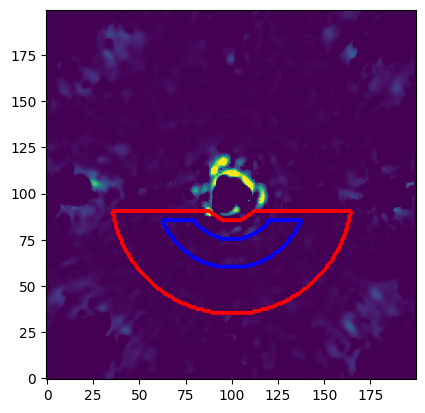

In [90]:
#print(total_intensity.shape, coherent_component.shape, incohenrent_component.shape)
print(rescaled_CDI.shape)
mask_CDI = perf.creatingMaskDH(200, 'circle', circ_rad=[25,40], circ_side='Top', circ_offset=15)
mask_score = perf.creatingMaskDH(200, 'circle', circ_rad=[15,65], circ_side='Top', circ_offset=10)

#rescaled_CDI = perf.rescale_CDI(coherent_component[0,4], total_intensity[0,4], mask_CDI)

plt.imshow(rescaled_CDI[1,4], vmin = 0, vmax =1e-4)
plt.contour(mask_CDI, colors = 'blue')
plt.contour(mask_score, colors = 'red')
plt.show()

/var/folders/ng/g787s6md5273_br1kd2x2vth0000gp/T/ipykernel_22351/2513542018.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=copy.copy(mpl.cm.get_cmap('Blues_r'))


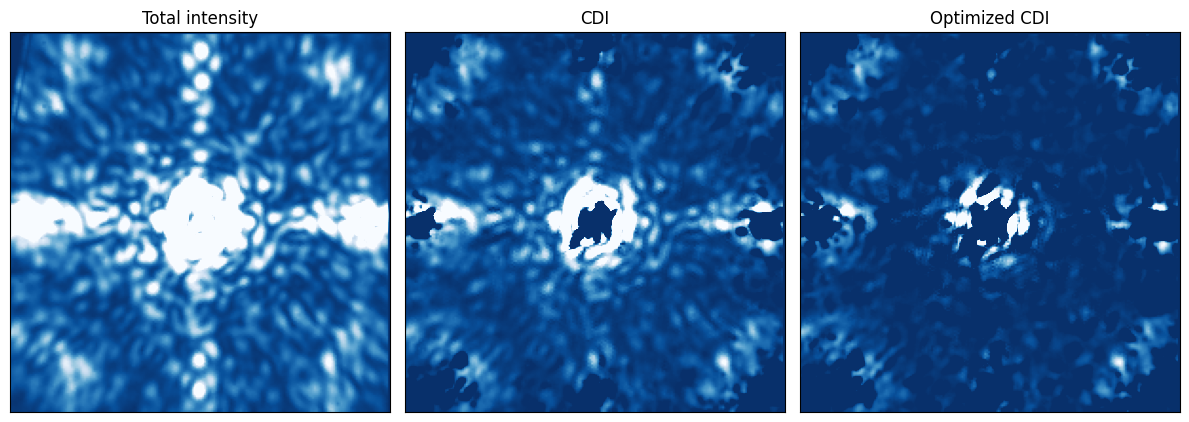

In [98]:
import copy
from matplotlib.colors import LogNorm
mask_score = perf.creatingMaskDH(200, 'circle', circ_rad=[20,55], circ_side='Top', circ_offset=10)
vmin = 0
vmax = 3e-5

iter = 0
wvl = 5

pup = total_intensity[iter,wvl]
img = incoherent_component[iter,wvl]
img2 = rescaled_CDI[iter,wvl]
norm = None

cmap=copy.copy(mpl.cm.jet)
cmap=copy.copy(mpl.cm.get_cmap('Blues_r'))
cmap.set_bad('black',1)

f1 = plt.figure(1, figsize=(12,5))#(12,3)#(12,6)
f1.clf()

ax1 = f1.add_subplot(131)
if norm == 'log':
    ax1.imshow(pup, cmap=cmap, norm=LogNorm(vmin, vmax))
else:
    ax1.imshow(pup, cmap=cmap, vmin = vmin, vmax = vmax)
ax1.set_xticks([])
ax1.set_yticks([])
#ax1.contour(mask_CDI, colors = 'green')
#ax1.contour(mask_score, colors = 'red')
ax1.set_title('Total intensity')

ax2 = f1.add_subplot(132)
if norm == 'log':
    im2 = ax2.imshow(img, cmap=cmap, norm=LogNorm(vmin, vmax))
else:
    im2 = ax2.imshow(img, cmap=cmap, vmin = vmin, vmax = vmax)
ax2.set_xticks([])
ax2.set_yticks([])
#ax2.contour(mask_CDI, colors = 'green')
#ax2.contour(mask_score, colors = 'red')
ax2.set_title('CDI')
#ax2.imshow(img, vmin = np.amin(pup), vmax = np.amax(pup), cmap="hot")

ax3 = f1.add_subplot(133)
if norm == 'log':
    im3 = ax3.imshow(img2, cmap=cmap, norm=LogNorm(vmin, vmax))
else:
    im3 = ax3.imshow(img2, cmap=cmap, vmin = vmin, vmax = vmax)
ax3.set_xticks([])
ax3.set_yticks([])
#ax3.contour(mask_CDI, colors = 'green')
#ax3.contour(mask_score, colors = 'red')
ax3.set_title('Optimized CDI')

f1.tight_layout()
#f1.subplots_adjust(bottom=0.2)#0.3#0.2
#cbar_ax = f1.add_axes([0.03, 0.08, 0.945, 0.08])#[0.03, 0.18, 0.945, 0.08]#[0.03, 0.08, 0.945, 0.08]
#cbar = f1.colorbar(im2, cax=cbar_ax, orientation='horizontal')
#cbar_ax.tick_params(labelsize=13)
#cbar_ax.xaxis.offsetText.set_fontsize(13)



In [93]:
wavelength = fits.getdata('/Users/apoitier/Documents/Research/Softwares/sphere_efc/sphere_efc/MatricesAndModel/IFS_OBS_H_wavelength.fits')
print(wavelength[3])

1166


In [100]:
contrast_tot = []
contrast_inco = []
contrast_inco_rescaled = []
for iter in np.arange(len(total_intensity)):
    contrast_per_wvl = []
    contrst_inco_per_wvl = []
    contrast_inco_rescaled_per_wvl = []

    for wvl in np.arange(total_intensity.shape[1]):
        contrst_tot = perf.contrast_global(total_intensity[iter,wvl],mask_score)[1]
        contrst_inco = perf.contrast_global(incoherent_component[iter,wvl],mask_score)[1]
        contrst_inco_rescaled = perf.contrast_global(rescaled_CDI[iter,wvl],mask_score)[1]
        contrast_per_wvl.append(contrst_tot)
        contrst_inco_per_wvl.append(contrst_inco)
        contrast_inco_rescaled_per_wvl.append(contrst_inco_rescaled)
    contrast_tot.append(contrast_per_wvl)
    contrast_inco.append(contrst_inco_per_wvl)
    contrast_inco_rescaled.append(contrast_inco_rescaled_per_wvl)
contrast_tot = np.array(contrast_tot)
contrast_inco = np.array(contrast_inco)
contrast_inco_rescaled = np.array(contrast_inco_rescaled)


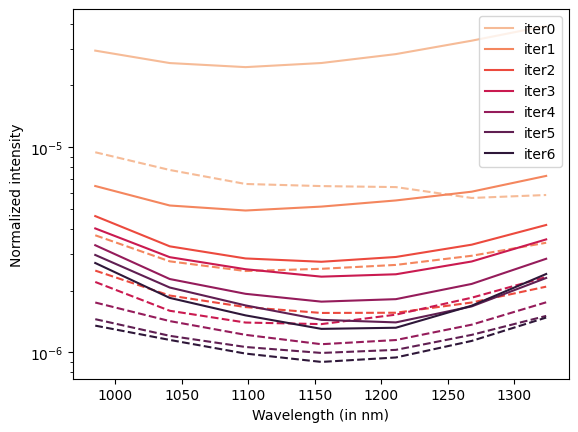

In [105]:
wavelength = fits.getdata('/Users/apoitier/Documents/Research/Softwares/sphere_efc/sphere_efc/MatricesAndModel/IFS_OBS_YJ_wavelength.fits')
import seaborn as sns
color = sns.color_palette("rocket_r", n_colors=len(total_intensity))
for iter in np.arange(len(total_intensity)):
    plt.plot(wavelength, contrast_tot[iter], color = color[iter],label = 'iter' + str(iter))
    plt.plot(wavelength, contrast_inco[iter], '--', color = color[iter] )
    #plt.plot(contrast_inco_rescaled)
plt.ylabel('Normalized intensity')
plt.xlabel('Wavelength (in nm)')
plt.yscale('log')
plt.legend()

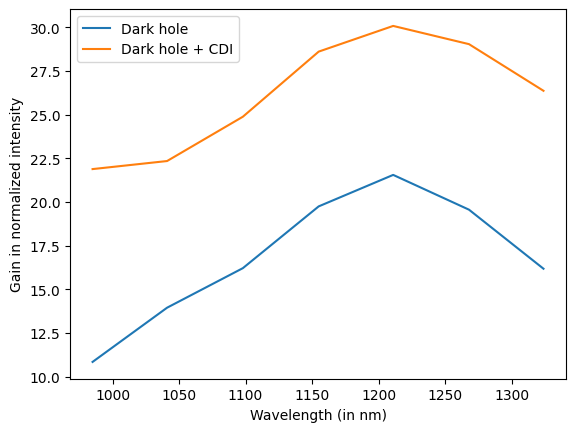

In [103]:
plt.plot(wavelength, contrast_tot[0]/contrast_tot[-1], label = 'Dark hole')
plt.plot(wavelength, contrast_tot[0]/contrast_inco[-1], label =   'Dark hole + CDI')
#plt.plot(wavelength, contrast_tot[0]/contrast_inco_rescaled[-1], label = 'Dark hole + optimized CDI')
plt.ylabel('Gain in normalized intensity')
plt.xlabel('Wavelength (in nm)')
plt.legend()

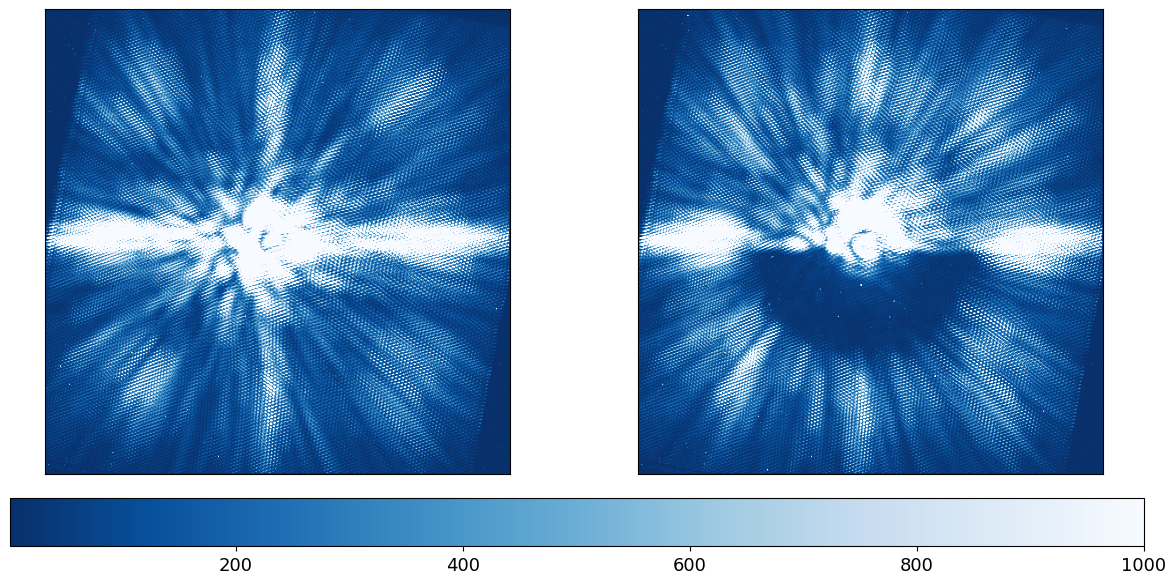

In [80]:
raw_IFS_image_0 = fits.getdata('/Users/apoitier/Documents/Research/Instruments/SPHERE/Data/cdi_files_06jun2026/06jun_internal_source/Experiment0012_IFS_iter0_coro_image_158_0001.fits')[0]
raw_IFS_image = fits.getdata('/Users/apoitier/Documents/Research/Instruments/SPHERE/Data/cdi_files_06jun2026/06jun_internal_source/Experiment0012_IFS_iter6_coro_image_158_0001.fits')[0]
dark_IFS_image_8s = fits.getdata('/Users/apoitier/Documents/Research/Instruments/SPHERE/Data/cdi_files_06jun2026/BKGRD/SPHERE_BKGRD_EFC_8s_157_0001.fits')[0]
perf.custom_plot(np.rot90(raw_IFS_image_0 - dark_IFS_image_8s), np.rot90(raw_IFS_image - dark_IFS_image_8s), vmin = 1, vmax = 1000)